## In case of efficiency, I set the episodes to be 5000 for running faster in the submitted version, the data in our presentation and report is 100,000 episodes (It may take half hour to run the whole notebook in that episodes).

## load & import

In [35]:
!pip install pypokerengine treys ipywidgets

## Simplifying Assumptions (Phase 1)

- **Heads-up only:** 2 players (agent vs. rule-based opponent)
- **Agent always acts second (in position):** the opponent's action is always observed before the agent decides, so Pot Odds = 0 unambiguously means the opponent checked
- **Fixed opponent strategy:** opponent follows a deterministic rule-based policy, making the environment stationary
- **No all-in:** maximum bet is capped at 1× pot to keep the action space bounded

### State Space (1,296 states = 9 × 3 × 4 × 4 × 3)

| Dimension | Values | Description |
|---|---|---|
| **Hand Type** | 0–8 | High Card / One Pair / Two Pair / Three of a Kind / Straight / Flush / Full House / Four of a Kind | Straight Flush 
| **Hand Strength** | 0–2 | Low / Mid / High — kicker strength within hand type |
| **Betting Round** | 0–3 | Preflop / Flop / Turn / River |
| **Pot Odds** | 0–3 | 0 (opponent checked) / Low / Medium / High — opponent's bet relative to pot |
| **Pot Size** | 0–2 | Small / Medium / Large — pot relative to agent's stack |

> **Note:** The opponent's hole cards are unobservable. Community card content is implicitly captured by Hand Type and Betting Round.

### Action Space (5 actions)

| Index | Action | Description |
|---|---|---|
| 0 | **Fold** | Forfeit the hand, lose chips committed |
| 1 | **Check** | Pass when no bet is facing the agent (Pot Odds = 0) |
| 2 | **Call** | Match the opponent's bet |
| 3 | **Small Bet** | Raise to ~1/2 pot |
| 4 | **Big Bet** | Raise to ~1 pot |

> Bet sizes are fixed pot multiples to preserve tabular tractability.

In [2]:
# config for state and action space
from pypokerengine.api.game import setup_config, start_poker
from pypokerengine.players import BasePokerPlayer

# Action indices
FOLD      = 0
CHECK     = 1
CALL      = 2
SMALL_BET = 3
BIG_BET   = 4

# State space dimensions
N_HAND_TYPE     = 9  # HC / 1P / 2P / 3oaK / Straight / Flush / FH / 4oaK / SF+Royal
N_HAND_STRENGTH = 3  # Low / Mid / High (relative rank within hand type)
N_STREET        = 4  # preflop / flop / turn / river
N_POT_ODDS      = 4  # 0=check / Low / Mid / High
N_POT_SIZE      = 3  # Small / Medium / Large
STATE_SIZE  = N_HAND_TYPE * N_HAND_STRENGTH * N_STREET * N_POT_ODDS * N_POT_SIZE  # 1296
ACTION_SIZE = 5

STREET_MAP = {'preflop': 0, 'flop': 1, 'turn': 2, 'river': 3}

print(f"State space: {STATE_SIZE}, Action space: {ACTION_SIZE}")


State space: 1296, Action space: 5


### state encoding

In [3]:
def encode_state(hand_type, hand_strength, street, pot_odds, pot_size):
    return (hand_type    * N_HAND_STRENGTH * N_STREET * N_POT_ODDS * N_POT_SIZE
            + hand_strength * N_STREET * N_POT_ODDS * N_POT_SIZE
            + street        * N_POT_ODDS * N_POT_SIZE
            + pot_odds      * N_POT_SIZE
            + pot_size)

def decode_state(idx):
    pot_size      = idx % N_POT_SIZE;      idx //= N_POT_SIZE
    pot_odds      = idx % N_POT_ODDS;      idx //= N_POT_ODDS
    street        = idx % N_STREET;        idx //= N_STREET
    hand_strength = idx % N_HAND_STRENGTH; idx //= N_HAND_STRENGTH
    hand_type     = idx
    return hand_type, hand_strength, street, pot_odds, pot_size

# Sanity check
for idx in [0, 100, 500, 1000, STATE_SIZE - 1]:
    decoded = decode_state(idx)
    assert encode_state(*decoded) == idx, f"Failed at idx={idx}"
print(f"encode/decode OK  (STATE_SIZE={STATE_SIZE})")


encode/decode OK  (STATE_SIZE=1296)


## Hand Evaluation


In [4]:
from treys import Card, Evaluator
evaluator = Evaluator()

SUIT_MAP = {'S': 's', 'H': 'h', 'D': 'd', 'C': 'c'}

def parse_cards(card_strs):
    """pypokerengine format -> treys card int"""
    result = []
    for c in card_strs:
        suit = SUIT_MAP[c[0]]
        rank = c[1]
        result.append(Card.new(rank + suit))
    return result

# treys rank class (0-9) -> our hand type (0-8)
# rank_class 0: Royal Flush (score=1, treys quirk)
# rank_class 1: Straight Flush (incl. Royal Flush, scores 1-10)
# Both map to hand_type 8 (SF/Royal)
RANK_CLASS_MAP = {
    0: 8,  # Royal Flush (treys returns rank_class=0 for score=1)
    1: 8,  # Straight Flush (excl. Royal Flush)
    2: 7,  # Four of a Kind
    3: 6,  # Full House
    4: 5,  # Flush
    5: 4,  # Straight
    6: 3,  # Three of a Kind
    7: 2,  # Two Pair
    8: 1,  # One Pair
    9: 0,  # High Card
}

# Score range per rank class (for computing hand_strength within type)
# treys: score 1 = best (Royal Flush), 7462 = worst (High Card 7-5-4-3-2)
RANK_CLASS_RANGE = {
    0: (1,    10),    # Royal Flush (rank_class=0, score always 1)
    1: (1,    10),    # Straight Flush (excl. Royal Flush, scores 2-10)
    2: (11,   166),   # Four of a Kind
    3: (167,  322),   # Full House
    4: (323,  1599),  # Flush
    5: (1600, 1609),  # Straight
    6: (1610, 2467),  # Three of a Kind
    7: (2468, 3325),  # Two Pair
    8: (3326, 6185),  # One Pair
    9: (6186, 7462),  # High Card
}

def evaluate_hand(hole_card, community_card):
    hole  = parse_cards(hole_card)
    board = parse_cards(community_card)

    if len(board) == 0:
        # Preflop: only 2 cards, evaluator needs >= 5
        # hand_type: pair (1) or high card (0)
        # hand_strength: based on high card rank (0-12)
        ranks = sorted([Card.get_rank_int(c) for c in hole], reverse=True)
        hand_type = 1 if ranks[0] == ranks[1] else 0
        high = ranks[0]
        if high <= 4:
            hand_strength = 0
        elif high <= 9:
            hand_strength = 1
        else:
            hand_strength = 2
        return hand_type, hand_strength

    score      = evaluator.evaluate(board, hole)
    rank_class = evaluator.get_rank_class(score)
    hand_type  = RANK_CLASS_MAP[rank_class]

    # hand_strength: relative rank within this hand type
    # lower score = stronger hand, so invert before bucketing
    lo, hi = RANK_CLASS_RANGE[rank_class]
    normalized = (hi - score) / (hi - lo + 1)
    if normalized < 0.33:
        hand_strength = 0   # Low
    elif normalized < 0.66:
        hand_strength = 1   # Mid
    else:
        hand_strength = 2   # High

    return hand_type, hand_strength

# Sanity checks
print(evaluate_hand(['SA', 'SK'], ['HQ', 'DJ', 'CT']))  # Straight  -> (4, ?)
print(evaluate_hand(['SA', 'SK'], []))                   # Preflop AA -> (1, 2)
print(evaluate_hand(['D2', 'H7'], ['SA', 'CK', 'HQ']))  # High card -> (0, ?)
print(evaluate_hand(['SA', 'HA'], ['DA', 'CA', 'SK']))  # Four Aces -> (7, ?)  not 8
print(evaluate_hand(['SA', 'SK'], ['HA', 'HK', 'HQ', 'HJ', 'HT']))  # Royal Flush -> (8, ?)


(4, 2)
(0, 2)
(0, 2)
(7, 2)
(8, 2)


In [9]:
def get_pot_odds(valid_actions, pot_amount):
    """
    Return discretized pot-odds bucket (0=opponent checked, 1=low, 2=mid, 3=high).
    0 = opponent checked (call amount is 0)
    1 = Low  (call/pot < 0.5)
    2 = Mid  (0.5 <= call/pot < 1.0)
    3 = High (call/pot >= 1.0)
    """
    call_amount = valid_actions[1]['amount']
    
    if call_amount == 0:
        return 0  # Opponent checked
    
    if pot_amount == 0:
        return 1  # Avoid division by zero
    
    ratio = call_amount / pot_amount
    if ratio < 0.5:
        return 1  # Lower than half pot
    elif ratio < 1.0:
        return 2  # Medium
    else:
        return 3  # Higher than pot


def get_pot_size(pot_amount, agent_stack):
    """
    Return discretized pot-size bucket relative to agent's stack (0=small, 1=medium, 2=large).
        0 = Small  (pot/stack < 0.1)
    1 = Medium (0.1 <= pot/stack < 0.3)
    2 = Large  (pot/stack >= 0.3)
    0 = Small  (pot/stack < 0.1)
    1 = Medium (0.1 <= pot/stack < 0.3)
    2 = Large  (pot/stack >= 0.3)
    """
    if agent_stack == 0:
        return 2
    
    ratio = pot_amount / agent_stack
    if ratio < 0.1:
        return 0  # Small
    elif ratio < 0.3:
        return 1  # Medium
    else:
        return 2  # Large

In [10]:
# Opponent decision matrix: OPPONENT_MATRIX[hand_type][hand_strength] -> aggression level
#   0 = passive  : no bet facing -> check;  bet facing -> fold
#   1 = neutral  : no bet facing -> check;  bet facing -> call
#   2 = aggressive: no bet facing -> bet;   bet facing -> call
#
#              Str=Low  Str=Mid  Str=High
OPPONENT_MATRIX = [
    [0, 0, 1],   # 0: High Card    — only high-strength high card calls
    [1, 1, 2],   # 1: One Pair     — low/mid pair calls, high pair bets
    [1, 2, 2],   # 2: Two Pair     — mid/high two pair bets
    [1, 2, 2],   # 3: Three of a Kind
    [2, 2, 2],   # 4: Straight     — all straights and above bet
    [2, 2, 2],   # 5: Flush
    [2, 2, 2],   # 6: Full House
    [2, 2, 2],   # 7: Four of a Kind
    [2, 2, 2],   # 8: Straight Flush / Royal Flush
]

class RuleBasedOpponent(BasePokerPlayer):
    """
    Rule-based opponent using a 9x3 (hand_type x hand_strength) decision matrix.
    Works uniformly across all streets including preflop.
    """
    def declare_action(self, valid_actions, hole_card, round_state):
        community_card = round_state['community_card']
        hand_type, hand_strength = evaluate_hand(hole_card, community_card)

        call_amount = valid_actions[1]['amount']
        raise_info  = valid_actions[2]['amount']
        raise_min   = raise_info['min']
        raise_max   = raise_info['max']
        pot_amount  = round_state['pot']['main']['amount']

        level = OPPONENT_MATRIX[hand_type][hand_strength]

        if level == 0:                          # passive
            if call_amount > 0:
                return 'fold', 0
            else:
                return 'call', 0                # check
        elif level == 1:                        # neutral
            return 'call', call_amount          # call or check
        else:                                   # aggressive
            if call_amount == 0:
                amount = max(raise_min, min(int(pot_amount * 0.5), raise_max))
                return 'raise', amount          # bet half pot
            else:
                return 'call', call_amount      # call (no re-raise for simplicity)

    def receive_game_start_message(self, game_info): pass
    def receive_round_start_message(self, round_count, hole_card, seats): pass
    def receive_street_start_message(self, street, round_state): pass
    def receive_game_update_message(self, action, round_state): pass
    def receive_round_result_message(self, winners, hand_info, round_state): pass


### Reward Function

| Outcome | Reward |
|---|---|
| Win | +P (pot size at conclusion) |
| Lose or Fold | −C (chips committed by agent this round) |
| Intermediate steps | 0 |

> Rewards are issued at the conclusion of each round (upon fold or showdown).


In [11]:
class PokerAgent(BasePokerPlayer):
    def __init__(self, policy_fn=None):
        super().__init__()
        self.policy_fn = policy_fn or (lambda state, valid_actions: 2)
        self.episode_log = []
        self._chips_start = None
        self._current_hole = None

    def receive_game_start_message(self, game_info):
        pass

    def receive_round_start_message(self, round_count, hole_card, seats):
        self._current_hole = hole_card
        self.episode_log = []
        for s in seats:
            if s['name'] == 'agent':
                self._chips_start = s['stack']

    def receive_street_start_message(self, street, round_state):
        pass

    def receive_game_update_message(self, action, round_state):
        pass

    def receive_round_result_message(self, winners, hand_info, round_state):
        for s in round_state['seats']:
            if s['name'] == 'agent':
                chips_end = s['stack']
        reward = chips_end - self._chips_start

        if self.episode_log:
            s, a, _ = self.episode_log[-1]
            self.episode_log[-1] = (s, a, reward)
        elif self._current_hole is not None:
            # Opponent folded preflop before agent acted — reward is lost without this.
            # Synthesize a preflop state (pot_odds=0, pot_size=0) with action CHECK
            # so training algorithms receive the positive "free win" signal.
            hand_type, hand_strength = evaluate_hand(self._current_hole, [])
            state = encode_state(hand_type, hand_strength, 0, 0, 0)
            self.episode_log.append((state, CHECK, reward))

    def declare_action(self, valid_actions, hole_card, round_state):
        community_card = round_state['community_card']
        pot_amount     = round_state['pot']['main']['amount']
        street         = STREET_MAP[round_state['street']]

        agent_stack = 1000
        for s in round_state['seats']:
            if s['name'] == 'agent':
                agent_stack = s['stack']

        hand_type, hand_strength = evaluate_hand(hole_card, community_card)
        pot_odds = get_pot_odds(valid_actions, pot_amount)
        pot_size = get_pot_size(pot_amount, agent_stack)

        state = encode_state(hand_type, hand_strength, street, pot_odds, pot_size)
        action_idx = self.policy_fn(state, valid_actions)
        action_str, amount = self._translate_action(action_idx, valid_actions, pot_amount)

        self.episode_log.append((state, action_idx, 0))
        return action_str, amount

    def _translate_action(self, action_idx, valid_actions, pot_amount):
        call_amount = valid_actions[1]['amount']
        raise_min   = valid_actions[2]['amount']['min']
        raise_max   = valid_actions[2]['amount']['max']

        if action_idx == 0:
            return 'fold', 0
        elif action_idx == 1:
            if call_amount == 0:
                return 'call', 0
            else:
                return 'call', call_amount
        elif action_idx == 2:
            return 'call', call_amount
        elif action_idx == 3:
            amount = max(raise_min, min(int(pot_amount * 0.5), raise_max))
            return 'raise', amount
        elif action_idx == 4:
            amount = max(raise_min, min(int(pot_amount * 1.0), raise_max))
            return 'raise', amount
        else:
            return 'call', call_amount


In [12]:
def run_episode(agent, opponent=None, initial_stack=1000, small_blind=10, verbose=0):
    """
    Run one single-hand episode.
    Returns agent.episode_log: list of (state, action, reward).
    """
    if opponent is None:
        opponent = RuleBasedOpponent()

    config = setup_config(
        max_round=1,
        initial_stack=initial_stack,
        small_blind_amount=small_blind
    )
    # Opponent registers first = small blind = acts first
    # Agent registers second = big blind = acts second (in position)
    config.register_player(name='opponent', algorithm=opponent)
    config.register_player(name='agent',    algorithm=agent)

    start_poker(config, verbose=verbose)
    return agent.episode_log


# smoke test
if __name__ == '__main__':
    agent = PokerAgent()
    total_reward = 0
    n = 100

    for i in range(n):
        log = run_episode(agent)
        if log:
            total_reward += log[-1][2]

    print(f"Ran {n} episodes")
    print(f"Total reward: {total_reward}")
    print(f"Avg reward per episode: {total_reward/n:.1f}")
    print("Simulator OK")

Ran 100 episodes
Total reward: 780
Avg reward per episode: 7.8
Simulator OK


## Training Process

In [13]:
import numpy as np
np.random.seed(42)

ALPHA       = 0.1
GAMMA       = 1
EPSILON_START     = 0.3
EPSILON_END = 0.01
N_EPISODES  = 5000
EPSILON_DECAY = (EPSILON_END / EPSILON_START) ** (1 / N_EPISODES)


def get_valid_action_indices(valid_actions):
    call_amount = valid_actions[1]['amount']
    indices = [0, 2, 3, 4]   # fold, call, small bet, big bet always valid
    if call_amount == 0:
        indices.append(1)    # check only valid when no bet
    return indices

def epsilon_greedy(state, valid_actions, Q, epsilon=EPSILON_START):
    valid_idx = get_valid_action_indices(valid_actions)

    if np.random.random() < epsilon:
        return np.random.choice(valid_idx)

    # If every Q value is exactly 0 (completely unvisited state),
    # choose randomly from non-fold actions instead of defaulting to fold.
    # This breaks the "all-zeros → fold → never explore" deadlock.
    if all(Q[state, i] == 0.0 for i in valid_idx):
        non_fold = [i for i in valid_idx if i != FOLD]
        return np.random.choice(non_fold)

    q_valid = {idx: Q[state, idx] for idx in valid_idx}
    return max(q_valid, key=q_valid.get)


In [14]:
def train_sarsa(n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START):
    Q = np.zeros((STATE_SIZE, ACTION_SIZE))
    reward_history = []

    for ep in range(n_episodes):
        epsilon = EPSILON_START * (EPSILON_DECAY ** ep)
        agent = PokerAgent(policy_fn=lambda s, va: epsilon_greedy(s, va, Q, epsilon))
        log = run_episode(agent)

        # SARSA update
        for i in range(len(log) - 1):
            s, a, r = log[i]
            s_next, a_next, _ = log[i + 1]
            # SARSA: Q(s,a) += α * [r + γ * Q(s',a') - Q(s,a)]
            Q[s, a] += alpha * (r + gamma * Q[s_next, a_next] - Q[s, a])

        # Terminal step
        if log:
            s, a, r = log[-1]
            # Terminal state: no next state, set Q(s',a') = 0
            Q[s, a] += alpha * (r - Q[s, a])

        reward_history.append(log[-1][2] if log else 0)

        if (ep + 1) % 5000 == 0:
            avg = np.mean(reward_history[-5000:])
            print(f"Episode {ep+1}, Avg reward (last 5000): {avg:.2f}")

    return Q, reward_history

In [15]:
def train_qlearning(n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START):
    Q = np.zeros((STATE_SIZE, ACTION_SIZE))
    reward_history = []

    for ep in range(n_episodes):
        epsilon = EPSILON_START * (EPSILON_DECAY ** ep)
        agent = PokerAgent(policy_fn=lambda s, va: epsilon_greedy(s, va, Q, epsilon))
        log = run_episode(agent)

        # Q-learning update
        for i in range(len(log) - 1):
            s, a, r = log[i]
            s_next, _, _ = log[i + 1]
            # Q-learning: Q(s,a) += α * [r + γ * max(Q(s',a')) - Q(s,a)]
            Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])

        # Terminal step
        if log:
            s, a, r = log[-1]
            Q[s, a] += alpha * (r - Q[s, a])

        reward_history.append(log[-1][2] if log else 0)

        if (ep + 1) % 5000 == 0:
            avg = np.mean(reward_history[-5000:])
            print(f"Episode {ep+1}, Avg reward (last 5000): {avg:.2f}")

    return Q, reward_history

In [16]:
def train_mc_afterstate(n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START):
    """
    Monte Carlo with After State value function V(S).
    Q_mc_sum/cnt tracks average returns per (S,A) for action selection only.
    V(S) is the primary After State value function updated via MC returns.
    """
    V        = np.zeros(STATE_SIZE)
    Q_mc_sum = np.zeros((STATE_SIZE, ACTION_SIZE))
    Q_mc_cnt = np.zeros((STATE_SIZE, ACTION_SIZE))
    reward_history = []

    for ep in range(n_episodes):
        epsilon = EPSILON_START * (EPSILON_DECAY ** ep)
        def mc_policy(s, va):
            valid_idx = get_valid_action_indices(va)
            if np.random.random() < epsilon:
                return np.random.choice(valid_idx)

            # If no non-fold action has ever been visited,
            # explore non-fold options instead of defaulting to fold.
            non_fold = [i for i in valid_idx if i != FOLD]
            if not any(Q_mc_cnt[s, i] > 0 for i in non_fold):
                return np.random.choice(non_fold)

            best, best_val = valid_idx[0], -np.inf
            for i in valid_idx:
                val = Q_mc_sum[s, i] / Q_mc_cnt[s, i] if Q_mc_cnt[s, i] > 0 else 0.0
                if val > best_val:
                    best_val = val
                    best = i
            return best

        agent = PokerAgent(policy_fn=mc_policy)
        log   = run_episode(agent)

        if not log:
            reward_history.append(0)
            continue

        # First-visit MC: compute discounted returns backward
        visited_sa = set()
        G = 0
        for t in reversed(range(len(log))):
            s, a, r = log[t]
            G = r + gamma * G
            V[s] += alpha * (G - V[s])
            if (s, a) not in visited_sa:
                visited_sa.add((s, a))
                Q_mc_sum[s, a] += G
                Q_mc_cnt[s, a] += 1

        reward_history.append(log[-1][2])

        if (ep + 1) % 5000 == 0:
            avg = np.mean(reward_history[-5000:])
            print(f"Episode {ep+1}, Avg reward (last 5000): {avg:.2f}")

    return V, Q_mc_sum, Q_mc_cnt, reward_history


## Run All Training

In [17]:
print("=== Training SARSA ===")
Q_sarsa, history_sarsa = train_sarsa()

print("\n=== Training Q-Learning ===")
Q_qlearn, history_qlearn = train_qlearning()

print("\n=== Training MC After State ===")
V_mc, Q_mc_sum, Q_mc_cnt, history_mc = train_mc_afterstate()

print("\nAll training complete.")


=== Training SARSA ===
Episode 5000, Avg reward (last 5000): 0.19

=== Training Q-Learning ===
Episode 5000, Avg reward (last 5000): 0.86

=== Training MC After State ===
Episode 5000, Avg reward (last 5000): 9.24

All training complete.


## Evaluation (in full version, the episodes should be 10000, this is for running and checking faster)

In [18]:
def evaluate_agent(policy_fn, n_episodes=1000):
    rewards, wins = [], 0
    for _ in range(n_episodes):
        agent = PokerAgent(policy_fn=policy_fn)
        log   = run_episode(agent)
        r = log[-1][2] if log else 0
        rewards.append(r)
        if r > 0:
            wins += 1
    return np.mean(rewards), wins / n_episodes

# --- Policy definitions ---
def random_policy(s, va):
    return np.random.choice(get_valid_action_indices(va))

def _non_fold_fallback(valid_idx):
    """Return check (1) or call (2) — never fold — for completely unvisited states."""
    return 1 if 1 in valid_idx else 2

def sarsa_greedy(s, va):
    valid_idx = get_valid_action_indices(va)
    if all(Q_sarsa[s, i] == 0.0 for i in valid_idx):
        return _non_fold_fallback(valid_idx)
    return max(valid_idx, key=lambda i: Q_sarsa[s, i])

def qlearn_greedy(s, va):
    valid_idx = get_valid_action_indices(va)
    if all(Q_qlearn[s, i] == 0.0 for i in valid_idx):
        return _non_fold_fallback(valid_idx)
    return max(valid_idx, key=lambda i: Q_qlearn[s, i])

def mc_greedy(s, va):
    valid_idx = get_valid_action_indices(va)
    non_fold = [i for i in valid_idx if i != FOLD]
    if not any(Q_mc_cnt[s, i] > 0 for i in non_fold):
        return _non_fold_fallback(valid_idx)
    best, best_val = valid_idx[0], -np.inf
    for i in valid_idx:
        val = Q_mc_sum[s, i] / Q_mc_cnt[s, i] if Q_mc_cnt[s, i] > 0 else 0.0
        if val > best_val:
            best_val, best = val, i
    return best

# --- Evaluate all agents ---
N_EVAL = 1000
print(f"Evaluating over {N_EVAL} episodes each...\n")

eval_policies = [
    ("Random",        random_policy),
    ("SARSA",         sarsa_greedy),
    ("Q-Learning",    qlearn_greedy),
    ("MC AfterState", mc_greedy),
]

results = {}
for name, policy in eval_policies:
    avg_r, win_rate = evaluate_agent(policy, N_EVAL)
    results[name] = (avg_r, win_rate)
    print(f"{name:16s}  avg reward: {avg_r:+.2f}  win rate: {win_rate:.1%}")

Evaluating over 1000 episodes each...

Random            avg reward: -3.66  win rate: 53.5%
SARSA             avg reward: +5.87  win rate: 71.8%
Q-Learning        avg reward: -4.45  win rate: 74.3%
MC AfterState     avg reward: +10.42  win rate: 35.8%


Q-Learning achieves the lowest reward but the highest win rate — appearing most conservative.

1. The rule-based opponent never bluffs.
   - States where weak hands face a bet are never visited.
   - Q values remain 0 for those states.

2. When all Q values are 0, the fallback is Call.
   - The agent calls even when it should not.
   - But a call neither wins big nor loses big.
   - Win rate stays high while average reward is low.

3. Q-learning's maximization bias:
   - max Q(S', a) overestimates certain state values.
   - But Q values for 'facing bet' states are 0.
   - This makes Fold look more attractive.
   - However the fallback mechanism overrides Fold.
   - The agent still Calls.

The rule-based opponent is too simple.
- A large number of states are never visited.
- Policy on those states is essentially random.
- Solution: self-play training.
  - The opponent will learn to bluff.
  - All states will be visited.
  - The agent learns a complete policy.


# Extension: 20-Hand Episode (no epsilon decay, 20,000 episodes) — Results & Analysis

## Results (as expected)

| Algorithm | Avg Reward | Win Rate |
|---|---|---|
| Random | -120.70 | 43.4% |
| SARSA | +161.70 | 85.4% |
| Q-Learning | +345.16 | 73.6% |
| MC AfterState | +365.52 | 87.6% |

## Why 20-hand episodes?

Each episode consists of 20 consecutive hands with a persistent stack, measuring long-run profitability in extended play.

## Analysis

**MC AfterState** achieves the best overall performance. MC uses actual discounted returns G rather than bootstrapped estimates. Longer episodes reduce return variance, leading to more stable V(S) estimates and the highest reward and win rate.

**Q-Learning** achieves the highest reward among TD methods. The off-policy max Q(S', a) receives more bootstrap signal over longer episodes, correctly capturing value-maximizing tendencies — betting aggressively in favorable spots drives up average reward, though win rate is slightly lower.

**SARSA** is the most conservative. Its on-policy nature follows the epsilon-greedy behavior policy closely — robust but cautious, with high win rate and lower reward than Q-Learning and MC.

## Unvisited states: a persistent structural limitation

Even with longer episodes, the rule-based opponent never bluffs. States where weak hands face a bet maintain Q values of 0. This structural limitation motivates **Phase 2: Self-Play** — an adaptive opponent that learns to bluff forces the agent to learn correct folding strategy in previously unvisited states.

---

## 20 ROUND Extensions (cont')
50,000-episode results:

| Algorithm | Avg Reward | Win Rate |
|---|---|---|
| Random | -101.80 | 47.4% |
| SARSA | +338.80 | 89.2% |
| Q-Learning | +282.34 | 70.6% |
| MC AfterState | +439.30 | 90.4% |

SARSA converges to the fully optimal policy.


In [19]:
# ── Strategy table: what does each agent do at River, facing various contexts?
# Rows: hand_type × hand_strength  |  Cols: two contexts (no bet vs facing bet)
# Context A: river, pot_odds=0 (no bet), pot_size=1 (medium)
# Context B: river, pot_odds=2 (medium bet), pot_size=1 (medium)

HAND_TYPE_NAMES = ['HC', '1P', '2P', '3oaK', 'Str', 'Flush', 'FH', '4oaK', 'SF/R']
HAND_STR_NAMES  = ['Low', 'Mid', 'High']
ACTION_NAMES    = ['Fold', 'Check', 'Call', 'SBet', 'BBet']

# dummy valid_actions for two contexts
def _dummy_va(call_amount):
    return [
        {'action': 'fold',  'amount': 0},
        {'action': 'call',  'amount': call_amount},
        {'action': 'raise', 'amount': {'min': 20, 'max': 500}},
    ]

VA_NOBET  = _dummy_va(0)   # opponent checked → check valid
VA_MIDBET = _dummy_va(50)  # opponent bet 50 → check invalid

print("=" * 72)
print(f"{'Strategy Table — River (pot_size=Medium)'}")
print(f"{'Hand':>10}  {'Str':>4}  "
      f"{'SARSA(no bet)':>13}  {'SARSA(facing bet)':>17}  "
      f"{'QL(no bet)':>10}  {'QL(facing bet)':>14}  "
      f"{'MC(no bet)':>10}  {'MC(facing bet)':>14}")
print("-" * 110)

for ht in range(N_HAND_TYPE):
    for hs in range(N_HAND_STRENGTH):
        state_nb = encode_state(ht, hs, 3, 0, 1)   # river, no bet,  medium pot
        state_mb = encode_state(ht, hs, 3, 2, 1)   # river, mid bet, medium pot

        s_nb  = ACTION_NAMES[sarsa_greedy(state_nb,  VA_NOBET)]
        s_mb  = ACTION_NAMES[sarsa_greedy(state_mb,  VA_MIDBET)]
        ql_nb = ACTION_NAMES[qlearn_greedy(state_nb, VA_NOBET)]
        ql_mb = ACTION_NAMES[qlearn_greedy(state_mb, VA_MIDBET)]
        mc_nb = ACTION_NAMES[mc_greedy(state_nb,     VA_NOBET)]
        mc_mb = ACTION_NAMES[mc_greedy(state_mb,     VA_MIDBET)]

        print(f"{HAND_TYPE_NAMES[ht]:>10}  {HAND_STR_NAMES[hs]:>4}  "
              f"{s_nb:>13}  {s_mb:>17}  "
              f"{ql_nb:>10}  {ql_mb:>14}  "
              f"{mc_nb:>10}  {mc_mb:>14}")
    print()

# ── Also check preflop states (only HC/1P possible) ──────────────────────────
print("=" * 72)
print("Preflop spot (SB calls → agent sees no bet, small pot)")
print(f"{'Hand':>10}  {'Str':>4}  {'SARSA':>8}  {'Q-Learn':>8}  {'MC':>8}")
print("-" * 50)
for ht in range(2):   # only HC, 1P at preflop
    for hs in range(N_HAND_STRENGTH):
        state = encode_state(ht, hs, 0, 0, 0)   # preflop, no bet, small pot
        print(f"{HAND_TYPE_NAMES[ht]:>10}  {HAND_STR_NAMES[hs]:>4}  "
              f"{ACTION_NAMES[sarsa_greedy(state, VA_NOBET)]:>8}  "
              f"{ACTION_NAMES[qlearn_greedy(state, VA_NOBET)]:>8}  "
              f"{ACTION_NAMES[mc_greedy(state, VA_NOBET)]:>8}")


Strategy Table — River (pot_size=Medium)
      Hand   Str  SARSA(no bet)  SARSA(facing bet)  QL(no bet)  QL(facing bet)  MC(no bet)  MC(facing bet)
--------------------------------------------------------------------------------------------------------------
        HC   Low           Call               Call        Call            Call       Check            Call
        HC   Mid          Check               Call       Check            Call        Call            Call
        HC  High           Call               Call        Call            Call        Fold            Call

        1P   Low           Call               Call       Check            Call       Check            Call
        1P   Mid           SBet               Call       Check            Call        BBet            Call
        1P  High           Call               Call        Call            Call        Fold            Call

        2P   Low           Call               Call       Check            Call        BBet       

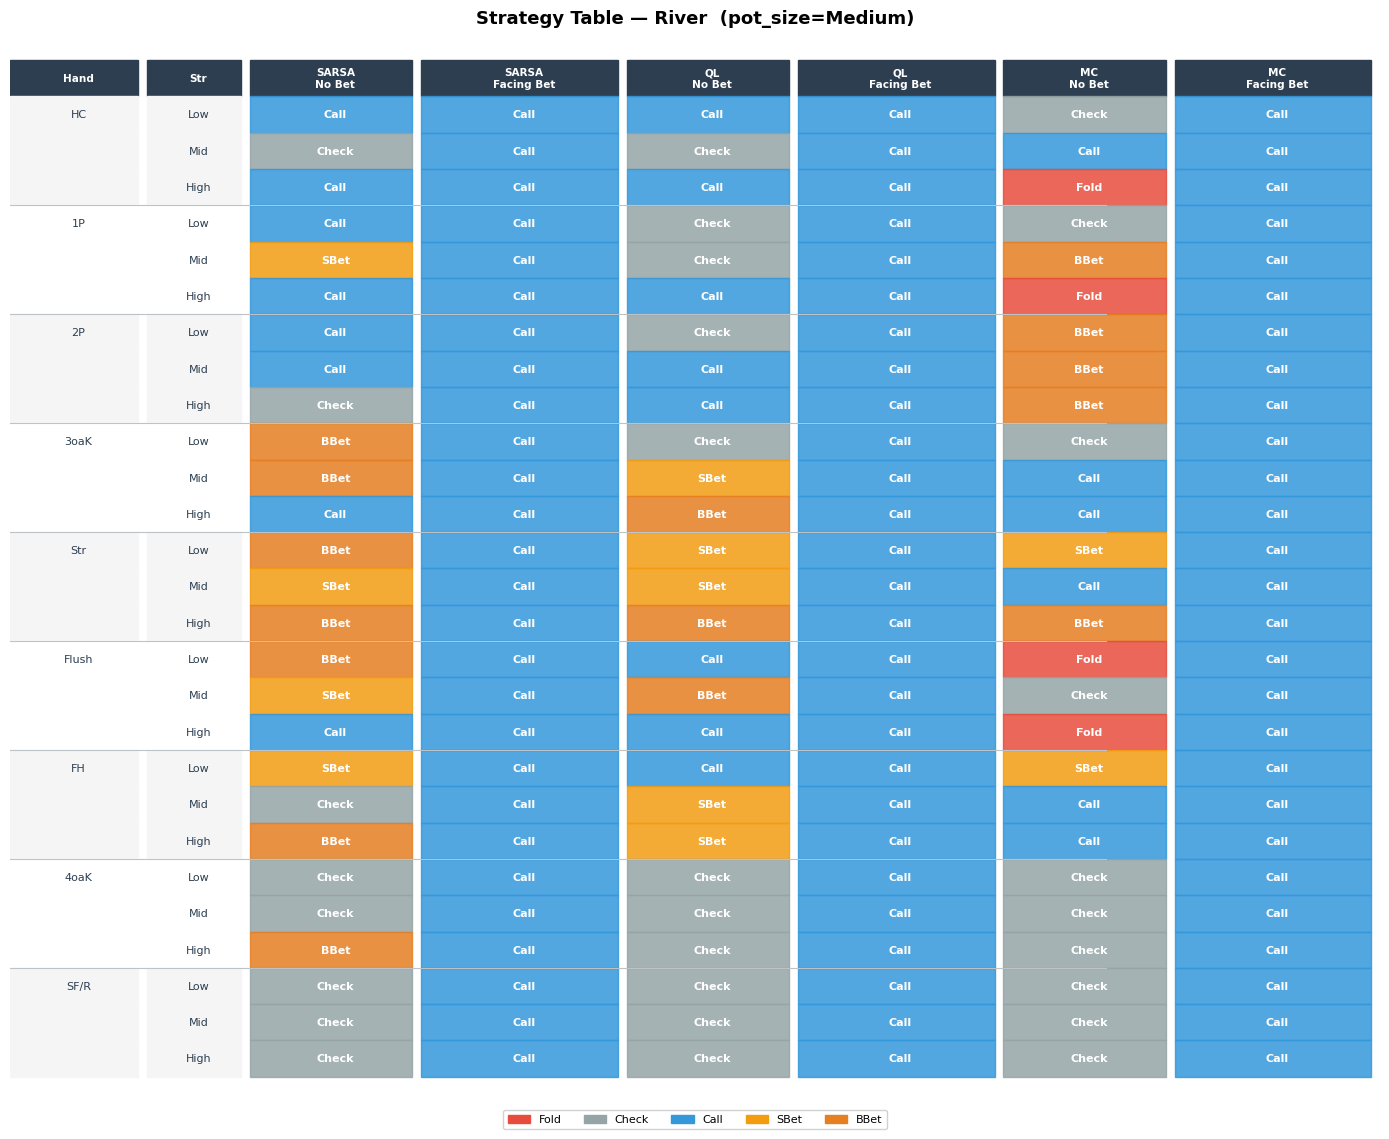

Saved → strategy_river.png


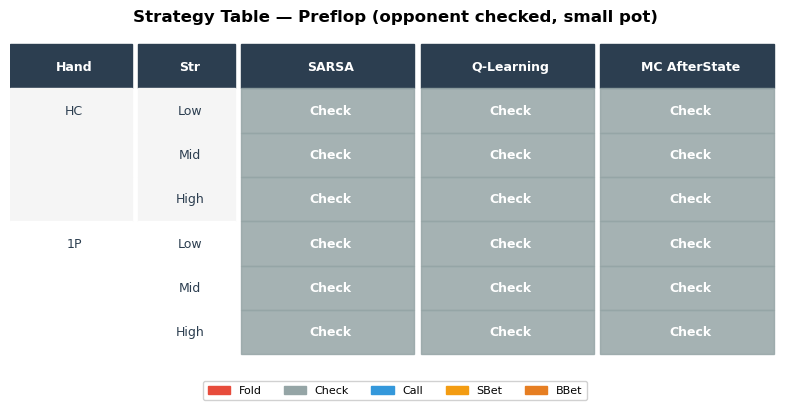

Saved → strategy_preflop.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

HAND_TYPE_NAMES = ['HC', '1P', '2P', '3oaK', 'Str', 'Flush', 'FH', '4oaK', 'SF/R']
HAND_STR_NAMES  = ['Low', 'Mid', 'High']
ACTION_NAMES    = ['Fold', 'Check', 'Call', 'SBet', 'BBet']
ACTION_COLORS   = {
    'Fold':  '#e74c3c',
    'Check': '#95a5a6',
    'Call':  '#3498db',
    'SBet':  '#f39c12',
    'BBet':  '#e67e22',
}

def _dummy_va(call_amount):
    return [
        {'action': 'fold',  'amount': 0},
        {'action': 'call',  'amount': call_amount},
        {'action': 'raise', 'amount': {'min': 20, 'max': 500}},
    ]

VA_NOBET  = _dummy_va(0)
VA_MIDBET = _dummy_va(50)

def plot_strategy_table(street, street_name, pot_odds_nb, pot_odds_mb,
                        pot_size, filename):
    # Build data
    rows = []
    for ht in range(N_HAND_TYPE):
        for hs in range(N_HAND_STRENGTH):
            state_nb = encode_state(ht, hs, street, pot_odds_nb, pot_size)
            state_mb = encode_state(ht, hs, street, pot_odds_mb, pot_size)
            rows.append([
                HAND_TYPE_NAMES[ht] if hs == 0 else '',
                HAND_STR_NAMES[hs],
                ACTION_NAMES[sarsa_greedy(state_nb,   VA_NOBET)],
                ACTION_NAMES[sarsa_greedy(state_mb,   VA_MIDBET)],
                ACTION_NAMES[qlearn_greedy(state_nb,  VA_NOBET)],
                ACTION_NAMES[qlearn_greedy(state_mb,  VA_MIDBET)],
                ACTION_NAMES[mc_greedy(state_nb,      VA_NOBET)],
                ACTION_NAMES[mc_greedy(state_mb,      VA_MIDBET)],
            ])

    n_rows = len(rows)
    col_labels = ['Hand', 'Str',
                  'SARSA\nNo Bet', 'SARSA\nFacing Bet',
                  'QL\nNo Bet',    'QL\nFacing Bet',
                  'MC\nNo Bet',    'MC\nFacing Bet']
    col_widths = [0.08, 0.06, 0.1, 0.12, 0.1, 0.12, 0.1, 0.12]

    fig, ax = plt.subplots(figsize=(14, n_rows * 0.38 + 1.2))
    ax.axis('off')

    # Header
    ax.set_title(f'Strategy Table — {street_name}  '
                 f'(pot_size={"Small" if pot_size==0 else "Medium" if pot_size==1 else "Large"})',
                 fontsize=13, fontweight='bold', pad=12)

    # Draw table
    x_starts = np.cumsum([0] + col_widths[:-1])
    header_y = 1.0
    row_h    = (header_y) / (n_rows + 1)

    # Header row
    for i, (label, xs, w) in enumerate(zip(col_labels, x_starts, col_widths)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xs, header_y - row_h), w - 0.005, row_h,
            boxstyle='square,pad=0', color='#2c3e50'))
        ax.text(xs + w/2, header_y - row_h/2, label,
                ha='center', va='center', color='white',
                fontsize=7.5, fontweight='bold')

    # Data rows
    for r, row in enumerate(rows):
        y = header_y - row_h * (r + 2)
        ht_idx = r // 3
        bg = '#f5f5f5' if ht_idx % 2 == 0 else '#ffffff'

        for c, (val, xs, w) in enumerate(zip(row, x_starts, col_widths)):
            # Cell background
            cell_color = bg
            if c >= 2:  # action columns
                cell_color = ACTION_COLORS.get(val, bg)
            ax.add_patch(mpatches.FancyBboxPatch(
                (xs, y), w - 0.005, row_h,
                boxstyle='square,pad=0', color=cell_color,
                alpha=0.85 if c >= 2 else 1.0))

            text_color = 'white' if c >= 2 else '#2c3e50'
            ax.text(xs + w/2, y + row_h/2, val,
                    ha='center', va='center',
                    color=text_color, fontsize=8,
                    fontweight='bold' if c >= 2 else 'normal')

        # Separator between hand types
        if r % 3 == 0 and r > 0:
            ax.axhline(y + row_h, color='#bdc3c7', linewidth=0.8,
                       xmin=0, xmax=sum(col_widths))

    ax.set_xlim(0, sum(col_widths))
    ax.set_ylim(header_y - row_h * (n_rows + 2), header_y + 0.02)

    # Legend
    legend_patches = [mpatches.Patch(color=c, label=a)
                      for a, c in ACTION_COLORS.items()]
    ax.legend(handles=legend_patches, loc='lower center',
              ncol=5, fontsize=8, framealpha=0.9,
              bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f'Saved → {filename}')


# ── River table ──
plot_strategy_table(
    street=3, street_name='River',
    pot_odds_nb=0, pot_odds_mb=2, pot_size=1,
    filename='strategy_river.png'
)

# ── Preflop table ──
def plot_preflop_table(filename):
    rows = []
    VA_PRE = _dummy_va(0)
    for ht in range(2):
        for hs in range(N_HAND_STRENGTH):
            state = encode_state(ht, hs, 0, 0, 0)
            rows.append([
                HAND_TYPE_NAMES[ht] if hs == 0 else '',
                HAND_STR_NAMES[hs],
                ACTION_NAMES[sarsa_greedy(state,  VA_PRE)],
                ACTION_NAMES[qlearn_greedy(state, VA_PRE)],
                ACTION_NAMES[mc_greedy(state,     VA_PRE)],
            ])

    col_labels = ['Hand', 'Str', 'SARSA', 'Q-Learning', 'MC AfterState']
    col_widths = [0.1, 0.08, 0.14, 0.14, 0.14]
    x_starts   = np.cumsum([0] + col_widths[:-1])
    n_rows     = len(rows)
    row_h      = 1.0 / (n_rows + 1)

    fig, ax = plt.subplots(figsize=(8, n_rows * 0.5 + 1.2))
    ax.axis('off')
    ax.set_title('Strategy Table — Preflop (opponent checked, small pot)',
                 fontsize=12, fontweight='bold', pad=12)

    header_y = 1.0
    for label, xs, w in zip(col_labels, x_starts, col_widths):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xs, header_y - row_h), w - 0.005, row_h,
            boxstyle='square,pad=0', color='#2c3e50'))
        ax.text(xs + w/2, header_y - row_h/2, label,
                ha='center', va='center', color='white',
                fontsize=9, fontweight='bold')

    for r, row in enumerate(rows):
        y  = header_y - row_h * (r + 2)
        bg = '#f5f5f5' if (r // 3) % 2 == 0 else '#ffffff'
        for c, (val, xs, w) in enumerate(zip(row, x_starts, col_widths)):
            cell_color = ACTION_COLORS.get(val, bg) if c >= 2 else bg
            ax.add_patch(mpatches.FancyBboxPatch(
                (xs, y), w - 0.005, row_h,
                boxstyle='square,pad=0', color=cell_color,
                alpha=0.85 if c >= 2 else 1.0))
            ax.text(xs + w/2, y + row_h/2, val,
                    ha='center', va='center',
                    color='white' if c >= 2 else '#2c3e50',
                    fontsize=9,
                    fontweight='bold' if c >= 2 else 'normal')

    ax.set_xlim(0, sum(col_widths))
    ax.set_ylim(header_y - row_h * (n_rows + 2), header_y + 0.02)

    legend_patches = [mpatches.Patch(color=c, label=a)
                      for a, c in ACTION_COLORS.items()]
    ax.legend(handles=legend_patches, loc='lower center',
              ncol=5, fontsize=8, framealpha=0.9,
              bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f'Saved → {filename}')

plot_preflop_table('strategy_preflop.png')

In [21]:
# Print Q-value distribution when facing a bet
for ht in range(3):  # Only weak hands HC/1P/2P
    for hs in range(N_HAND_STRENGTH):
        state = encode_state(ht, hs, 3, 2, 1)  # river, facing bet, medium pot
        print(f"{HAND_TYPE_NAMES[ht]} {HAND_STR_NAMES[hs]}: "
              f"Q_sarsa={[f'{Q_sarsa[state,i]:.2f}' for i in range(5)]}")

HC Low: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
HC Mid: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
HC High: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
1P Low: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
1P Mid: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
1P High: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
2P Low: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
2P Mid: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']
2P High: Q_sarsa=['0.00', '0.00', '0.00', '0.00', '0.00']


Because the opponent is rule-based, some states are never visited, which causes Q-learning's training to be incomplete for those states.


In [22]:
# ── Diagnostic: verify reward and Q values ───────────────────────────────────
print("=== Reward diagnosis: 10-episode sample ===")
for i in range(10):
    agent_diag = PokerAgent(policy_fn=lambda s, va: 1 if 1 in get_valid_action_indices(va) else 2)
    log = run_episode(agent_diag)
    if log:
        s0, a0, _ = log[0]
        ht0, hs0, st0, po0, ps0 = decode_state(s0)
        print(f"  ep{i}: steps={len(log)}, chips_start={agent_diag._chips_start}, "
              f"first_street={['pre','flop','turn','river'][st0]}, "
              f"first_action={['Fold','Check','Call','SBet','BBet'][a0]}, "
              f"reward={log[-1][2]}")
    else:
        print(f"  ep{i}: empty log, chips_start={agent_diag._chips_start}")

print("\n=== Q values for preflop states (SARSA) ===")
print(f"{'Hand':>10} {'Str':>4} {'Fold':>8} {'Check':>8} {'Call':>8} {'SBet':>8} {'BBet':>8}")
for ht in range(2):
    for hs in range(3):
        s = encode_state(ht, hs, 0, 0, 0)
        vals = [Q_sarsa[s, i] for i in range(5)]
        print(f"{HAND_TYPE_NAMES[ht]:>10} {HAND_STR_NAMES[hs]:>4} "
              f"{vals[0]:>8.2f} {vals[1]:>8.2f} {vals[2]:>8.2f} {vals[3]:>8.2f} {vals[4]:>8.2f}")

print("\n=== MC visit counts for preflop states ===")
for ht in range(2):
    for hs in range(3):
        s = encode_state(ht, hs, 0, 0, 0)
        cnts = [int(Q_mc_cnt[s, i]) for i in range(5)]
        print(f"{HAND_TYPE_NAMES[ht]:>10} {HAND_STR_NAMES[hs]:>4}  "
              f"Fold={cnts[0]} Check={cnts[1]} Call={cnts[2]} SBet={cnts[3]} BBet={cnts[4]}")


=== Reward diagnosis: 10-episode sample ===
  ep0: steps=1, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep1: steps=4, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep2: steps=7, chips_start=990, first_street=pre, first_action=Call, reward=-150
  ep3: steps=1, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep4: steps=7, chips_start=990, first_street=pre, first_action=Call, reward=170
  ep5: steps=1, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep6: steps=1, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep7: steps=1, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep8: steps=1, chips_start=990, first_street=pre, first_action=Call, reward=30
  ep9: steps=6, chips_start=990, first_street=pre, first_action=Call, reward=-70

=== Q values for preflop states (SARSA) ===
      Hand  Str     Fold    Check     Call     SBet     BBet
        HC  Low     0.00     0.00     0.00    

## Learning Curves & Results

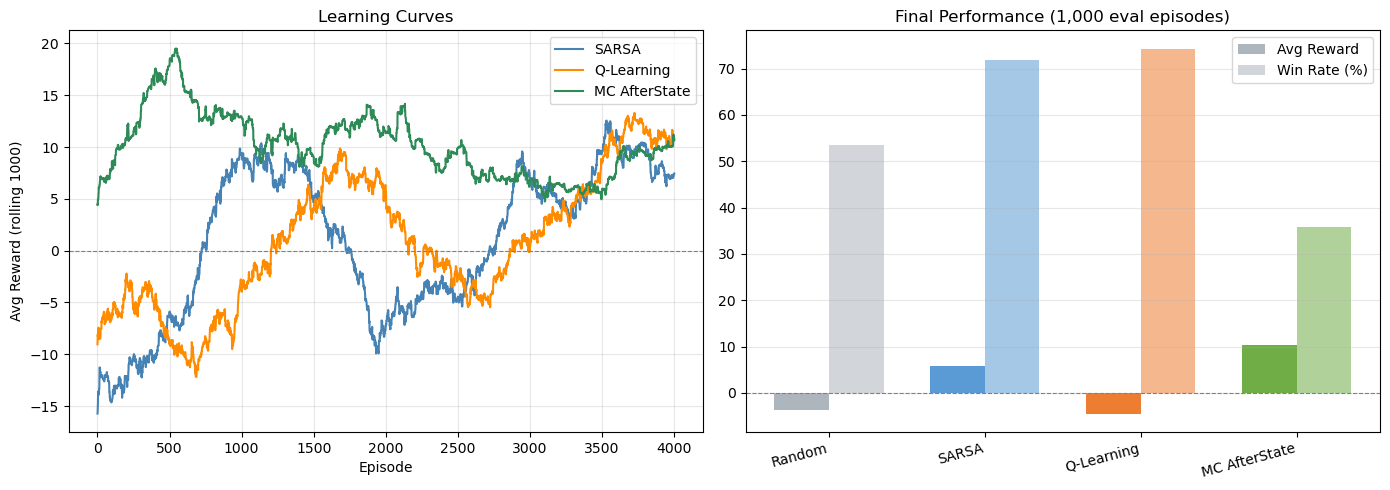

Saved → results.png


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Learning curves (rolling mean) ----
ax = axes[0]
WINDOW = 1000
COLORS = {'SARSA': 'steelblue', 'Q-Learning': 'darkorange', 'MC AfterState': 'seagreen'}

for name, hist in [('SARSA', history_sarsa), ('Q-Learning', history_qlearn), ('MC AfterState', history_mc)]:
    smoothed = np.convolve(hist, np.ones(WINDOW) / WINDOW, mode='valid')
    ax.plot(smoothed, label=name, color=COLORS[name], linewidth=1.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel(f'Avg Reward (rolling {WINDOW})')
ax.set_title('Learning Curves')
ax.legend()
ax.grid(alpha=0.3)

# ---- Right: Bar chart of final evaluation ----
ax2 = axes[1]
names     = list(results.keys())
avg_rwds  = [results[n][0] for n in names]
win_rates = [results[n][1] * 100 for n in names]
bar_colors = ['#adb5bd', '#5b9bd5', '#ed7d31', '#70ad47']

x, w = np.arange(len(names)), 0.35
ax2.bar(x - w/2, avg_rwds,  w, label='Avg Reward',   color=bar_colors)
ax2.bar(x + w/2, win_rates, w, label='Win Rate (%)', color=bar_colors, alpha=0.55)

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=15, ha='right')
ax2.set_title(f'Final Performance ({N_EVAL:,} eval episodes)')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()
print("Saved → results.png")


## Extension 2: Self-Play
### Step 1: Self-Play Training 


In [24]:


class SelfPlayOpponent(BasePokerPlayer):
    """RL-driven opponent using a frozen Q-table."""
    def __init__(self, Q, epsilon = EPSILON_START):
        super().__init__()
        self.Q       = Q
        self.epsilon = epsilon

    def declare_action(self, valid_actions, hole_card, round_state):
        community_card = round_state['community_card']
        pot_amount     = round_state['pot']['main']['amount']
        street         = STREET_MAP[round_state['street']]

        opp_stack = 1000
        for s in round_state['seats']:
            if s['name'] == 'opponent':
                opp_stack = s['stack']

        hand_type, hand_strength = evaluate_hand(hole_card, community_card)
        pot_odds = get_pot_odds(valid_actions, pot_amount)
        pot_size = get_pot_size(pot_amount, opp_stack)
        state    = encode_state(hand_type, hand_strength, street, pot_odds, pot_size)

        valid_idx = get_valid_action_indices(valid_actions)
        if np.random.random() < self.epsilon:
            action_idx = np.random.choice(valid_idx)
        elif all(self.Q[state, i] == 0.0 for i in valid_idx):
            non_fold   = [i for i in valid_idx if i != FOLD]
            action_idx = np.random.choice(non_fold)
        else:
            action_idx = max(valid_idx, key=lambda i: self.Q[state, i])

        call_amount = valid_actions[1]['amount']
        raise_min   = valid_actions[2]['amount']['min']
        raise_max   = valid_actions[2]['amount']['max']
        pot         = pot_amount

        if action_idx == FOLD:       return 'fold', 0
        elif action_idx == CHECK:    return 'call', 0 if call_amount == 0 else call_amount
        elif action_idx == CALL:     return 'call', call_amount
        elif action_idx == SMALL_BET:
            amt = max(raise_min, min(int(pot * 0.5), raise_max))
            return 'raise', amt
        else:
            amt = max(raise_min, min(int(pot * 1.0), raise_max))
            return 'raise', amt

    def receive_game_start_message(self, game_info): pass
    def receive_round_start_message(self, round_count, hole_card, seats): pass
    def receive_street_start_message(self, street, round_state): pass
    def receive_game_update_message(self, action, round_state): pass
    def receive_round_result_message(self, winners, hand_info, round_state): pass


def run_episode_selfplay(Q_opponent, agent_factory,
                         initial_stack=1000, small_blind=10):
    """Single-hand self-play episode."""
    agent    = agent_factory()
    opponent = SelfPlayOpponent(Q_opponent)

    config = setup_config(
        max_round=1,
        initial_stack=initial_stack,
        small_blind_amount=small_blind
    )
    config.register_player(name='opponent', algorithm=opponent)
    config.register_player(name='agent',    algorithm=agent)
    start_poker(config, verbose=0)

    return agent.episode_log


def train_selfplay(n_episodes=N_EPISODES, update_freq=5000,
                   alpha=ALPHA, gamma=1.0,
                   method='qlearning'):  # 'qlearning', 'sarsa', 'mc'
    Q1     = np.zeros((STATE_SIZE, ACTION_SIZE))
    Q2     = np.zeros((STATE_SIZE, ACTION_SIZE))
    V1     = np.zeros(STATE_SIZE)           # MC After State
    Q1_sum = np.zeros((STATE_SIZE, ACTION_SIZE))  # MC action selection
    Q1_cnt = np.zeros((STATE_SIZE, ACTION_SIZE))
    all_rewards = []

    for ep in range(n_episodes):
        epsilon_t = EPSILON_START * (EPSILON_END / EPSILON_START) ** (ep / n_episodes)
        if ep % update_freq == 0 and ep > 0:
            Q2 = Q1.copy()

        if method == 'mc':
            def mc_sp_policy(s, va):
                valid_idx = get_valid_action_indices(va)
                if np.random.random() < epsilon_t:
                    return np.random.choice(valid_idx)
                non_fold = [i for i in valid_idx if i != FOLD]
                if not any(Q1_cnt[s, i] > 0 for i in non_fold):
                    return np.random.choice(non_fold)
                best, best_val = valid_idx[0], -np.inf
                for i in valid_idx:
                    val = Q1_sum[s, i] / Q1_cnt[s, i] if Q1_cnt[s, i] > 0 else 0.0
                    if val > best_val:
                        best_val = val
                        best = i
                return best
            agent_factory = lambda: PokerAgent(policy_fn=mc_sp_policy)
        else:
            agent_factory = lambda: PokerAgent(
                policy_fn=lambda s, va: epsilon_greedy(s, va, Q1, epsilon_t)
            )

        log = run_episode_selfplay(Q_opponent=Q2, agent_factory=agent_factory)

        if method == 'sarsa':
            for i in range(len(log) - 1):
                s, a, r = log[i]
                s_next, a_next, _ = log[i + 1]
                Q1[s, a] += alpha * (r + gamma * Q1[s_next, a_next] - Q1[s, a])
            if log:
                s, a, r = log[-1]
                Q1[s, a] += alpha * (r - Q1[s, a])

        elif method == 'qlearning':
            for i in range(len(log) - 1):
                s, a, r = log[i]
                s_next, _, _ = log[i + 1]
                Q1[s, a] += alpha * (r + gamma * np.max(Q1[s_next]) - Q1[s, a])
            if log:
                s, a, r = log[-1]
                Q1[s, a] += alpha * (r - Q1[s, a])

        elif method == 'mc':
            visited_sa = set()
            G = 0
            for t in reversed(range(len(log))):
                s, a, r = log[t]
                G = r + gamma * G
                V1[s] += alpha * (G - V1[s])
                if (s, a) not in visited_sa:
                    visited_sa.add((s, a))
                    Q1_sum[s, a] += G
                    Q1_cnt[s, a] += 1

        episode_reward = sum(r for _, _, r in log if r != 0)
        all_rewards.append(episode_reward)

        if (ep + 1) % 5000 == 0:
            avg = np.mean(all_rewards[-5000:])
            print(f"Episode {ep+1}, Avg reward (last 5000): {avg:.2f}")

    if method == 'mc':
        return Q1_sum, Q1_cnt, V1, Q2, all_rewards
    return Q1, Q2, all_rewards

In [25]:


print("=== Self-Play: SARSA vs SARSA ===")
Q_sp_sarsa, _, history_sp_sarsa = train_selfplay(
    n_episodes=N_EPISODES, update_freq=1000,
    alpha=ALPHA, gamma=1.0,method='sarsa'
)

print("\n=== Self-Play: Q-Learning vs Q-Learning ===")
Q_sp_ql, _, history_sp_ql = train_selfplay(
    n_episodes=N_EPISODES, update_freq=1000,
    alpha=ALPHA, gamma=1.0,method='qlearning'
)

print("\n=== Self-Play: MC vs MC ===")
Q_sp_mc_sum, Q_sp_mc_cnt, V_sp_mc, _, history_sp_mc = train_selfplay(
    n_episodes=N_EPISODES, update_freq=1000,
    alpha=ALPHA, gamma=1.0, method='mc'
)

print("\nAll self-play training complete.")

=== Self-Play: SARSA vs SARSA ===
Episode 5000, Avg reward (last 5000): 105.96

=== Self-Play: Q-Learning vs Q-Learning ===
Episode 5000, Avg reward (last 5000): 70.43

=== Self-Play: MC vs MC ===
Episode 5000, Avg reward (last 5000): 3.88

All self-play training complete.


In [27]:
def sp_greedy(Q, s, va):
    valid_idx = get_valid_action_indices(va)
    if all(Q[s, i] == 0.0 for i in valid_idx):
        return _non_fold_fallback(valid_idx)
    return max(valid_idx, key=lambda i: Q[s, i])

def evaluate_agent_vs_agent(Q_agent, Q_opponent, n_episodes=1000):
    """Agent (Q_agent) plays against RL opponent (Q_opponent)."""
    rewards = []
    for _ in range(n_episodes):
        log = run_episode_selfplay(
            Q_opponent=Q_opponent,
            agent_factory=lambda: PokerAgent(
                policy_fn=lambda s, va: sp_greedy(Q_agent, s, va)
            )
        )
        r = sum(reward for _, _, reward in log if reward != 0)
        rewards.append(r)
    return np.mean(rewards)


N_EVAL = 1000
print(f"{'Matchup':35s}  {'Avg Reward':>12}")
print("-" * 52)

# Phase1 vs Phase1
r = evaluate_agent_vs_agent(Q_sarsa, Q_sarsa)
print(f"{'Phase1 SARSA vs Phase1 SARSA':35s}  {r:>+12.2f}")

r = evaluate_agent_vs_agent(Q_qlearn, Q_qlearn)
print(f"{'Phase1 QL vs Phase1 QL':35s}  {r:>+12.2f}")

# Self-play vs Phase1
r = evaluate_agent_vs_agent(Q_sp_sarsa, Q_sarsa)
print(f"{'SP-SARSA vs Phase1 SARSA':35s}  {r:>+12.2f}")

r = evaluate_agent_vs_agent(Q_sp_ql, Q_qlearn)
print(f"{'SP-QL vs Phase1 QL':35s}  {r:>+12.2f}")

# Self-play vs Self-play
r = evaluate_agent_vs_agent(Q_sp_sarsa, Q_sp_sarsa)
print(f"{'SP-SARSA vs SP-SARSA':35s}  {r:>+12.2f}")

r = evaluate_agent_vs_agent(Q_sp_ql, Q_sp_ql)
print(f"{'SP-QL vs SP-QL':35s}  {r:>+12.2f}")

Matchup                                Avg Reward
----------------------------------------------------
Phase1 SARSA vs Phase1 SARSA                +3.06
Phase1 QL vs Phase1 QL                      +7.95
SP-SARSA vs Phase1 SARSA                  +144.81
SP-QL vs Phase1 QL                        +145.23
SP-SARSA vs SP-SARSA                      +122.53
SP-QL vs SP-QL                            +123.06


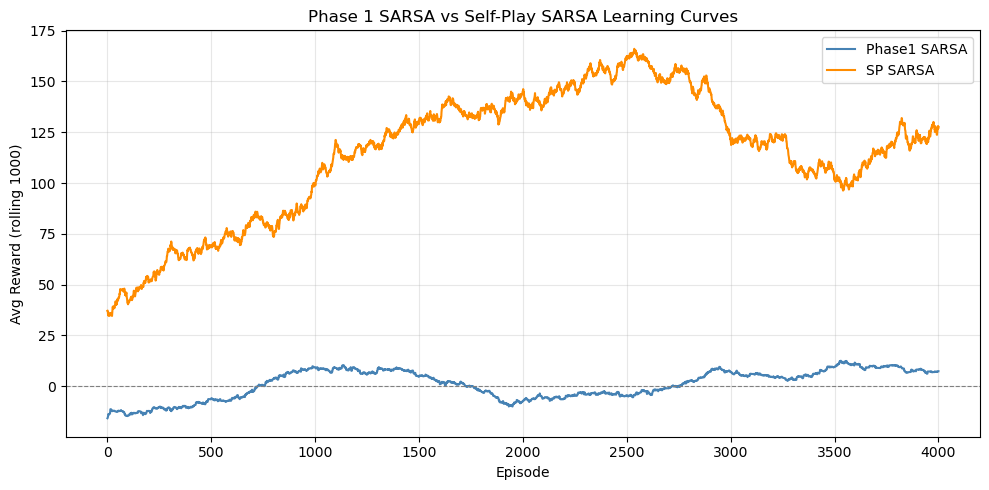

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
WINDOW = 1000

for name, hist, color in [
    ('Phase1 SARSA',    history_sarsa,    'steelblue'),
    ('SP SARSA',        history_sp_sarsa, 'darkorange'),
]:
    smoothed = np.convolve(hist, np.ones(WINDOW)/WINDOW, mode='valid')
    ax.plot(smoothed, label=name, color=color, linewidth=1.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel(f'Avg Reward (rolling {WINDOW})')
ax.set_title('Phase 1 SARSA vs Self-Play SARSA Learning Curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_selfplay.png', dpi=150)
plt.show()

In [30]:
# Diagnostic
log = run_episode_selfplay(
    Q_opponent=Q_sp_ql,
    agent_factory=lambda: PokerAgent(
        policy_fn=lambda s, va: sp_greedy(Q_sp_ql, s, va)
    )
)
print(f"Steps: {len(log)}")
print(f"Actions: {[a for _,a,_ in log]}")
print(f"Rewards: {[r for _,_,r in log if r != 0]}")

Steps: 5
Actions: [4, 4, 4, 4, 1]
Rewards: [640]


Both agents converge to:
'Regardless of the opponent's action, raising is always optimal.'
- Both agents raise every hand.
- Neither has a unilateral incentive to deviate.
- This is a Nash Equilibrium.
- But a degenerate one (suboptimal for both parties).

Self-play early stage:
- Both agents explore randomly.
- Raising wins a large pot => positive reward.
- Q(raise) gets reinforced.

Both agents simultaneously learn that raising is good.
- They reinforce each other's raising behavior.
- Converge to a 'both raise' equilibrium.
- Rather than the truly optimal strategy.

Reference note (AI-sourced):
'Both self-play agents converge to a degenerate Nash Equilibrium where raising dominates regardless of hand strength -- a known failure mode in multi-agent RL where agents reinforce each other's suboptimal strategies.'


## Interactive Demo — Play Against Trained Agent

Human plays as **Small Blind** (acts first each street).  
Trained Q-Learning agent plays as **Big Blind** (acts second, same as its training role).

In [31]:
import random as _rand

# ── Card display helpers ──────────────────────────────────────────────────────
_SUIT_SYM = {'s': '♠', 'h': '♥', 'd': '♦', 'c': '♣'}
_RANK_SYM = {'2':'2','3':'3','4':'4','5':'5','6':'6','7':'7',
             '8':'8','9':'9','T':'10','J':'J','Q':'Q','K':'K','A':'A'}

def _card_html(c_int):
    s    = Card.int_to_str(c_int)
    suit = _SUIT_SYM[s[1]]
    rank = _RANK_SYM[s[0]]
    col  = 'crimson' if s[1] in ('h', 'd') else '#111'
    return (f'<span style="display:inline-block;width:44px;height:60px;line-height:60px;'
            f'text-align:center;border:1px solid #ccc;border-radius:6px;'
            f'background:#fff;font-size:1.1em;font-weight:bold;color:{col};margin:2px">'
            f'{rank}{suit}</span>')

def _hidden_card_html():
    return ('<span style="display:inline-block;width:44px;height:60px;line-height:60px;'
            'text-align:center;border:1px solid #aaa;border-radius:6px;'
            'background:#4a90d9;font-size:1.4em;margin:2px">🂠</span>')

def _hand_html(cards, hidden=False):
    if hidden:
        return ''.join(_hidden_card_html() for _ in cards)
    return ''.join(_card_html(c) for c in cards)

def _treys_to_poke(c_int):
    s = Card.int_to_str(c_int)
    return {'s':'S','h':'H','d':'D','c':'C'}[s[1]] + s[0]


# ── Game state machine ────────────────────────────────────────────────────────
class PokerInteractiveGame:
    STACK = 1000
    SB    = 10
    BB    = 20

    def __init__(self, policy_fn):
        self.policy_fn  = policy_fn   # (state_idx, valid_actions) -> action_idx
        self.human_wins = 0
        self.agent_wins = 0
        self.draws      = 0
        self.game_num   = 0
        self.reset()
        self.human_reward_log = []  # track reward history for diagnostics

    def reset(self):
        self.game_num += 1
        deck = list(full_deck)
        _rand.shuffle(deck)

        self.human_hand    = deck[:2]
        self.agent_hand    = deck[2:4]
        self.all_community = deck[4:9]   # pre-deal 5 board cards

        self.human_stack = self.STACK - self.SB
        self.agent_stack = self.STACK - self.BB
        self.pot         = self.SB + self.BB
        self.street      = 0             # 0=preflop, 1=flop, 2=turn, 3=river

        # Preflop: human (SB=10) owes 10 more to match BB=20
        self.human_bet_street = self.SB
        self.agent_bet_street = self.BB
        self.to_call_human    = self.BB - self.SB   # 10

        self.game_over    = False
        self.show_agent   = False        # reveal agent cards at showdown
        self.log_lines    = []
        self.agent_msg    = "posted BB"
        # phase: 'human_turn' | 'human_call_fold' | 'done'
        self.phase        = 'human_turn'

    # ── helpers ───────────────────────────────────────────────────────────────
    @property
    def community(self):
        n = [0, 3, 4, 5][self.street]
        return self.all_community[:n]

    def _build_valid_actions(self):
        """valid_actions as seen by the agent (acts second)."""
        to_call = max(0, self.human_bet_street - self.agent_bet_street)
        max_r   = self.agent_stack
        min_r   = to_call + self.BB
        if min_r > max_r:
            min_r = max_r
        return [
            {'action': 'fold',  'amount': 0},
            {'action': 'call',  'amount': min(to_call, self.agent_stack)},
            {'action': 'raise', 'amount': {'min': min_r, 'max': max_r}},
        ]

    # ── agent step ────────────────────────────────────────────────────────────
    def _agent_act(self):
        va   = self._build_valid_actions()
        comm = [_treys_to_poke(c) for c in self.community]
        hand = [_treys_to_poke(c) for c in self.agent_hand]

        ht, hs = evaluate_hand(hand, comm)
        po     = get_pot_odds(va, self.pot)
        ps     = get_pot_size(self.pot, self.agent_stack)
        state  = encode_state(ht, hs, self.street, po, ps)

        valid_idx  = get_valid_action_indices(va)
        action_idx = self.policy_fn(state, va)
        if action_idx not in valid_idx:
            action_idx = valid_idx[0]

        call_amt  = va[1]['amount']
        raise_min = va[2]['amount']['min']
        raise_max = va[2]['amount']['max']

        if action_idx == 0:                          # fold
            self.agent_msg = "Agent folds"
            self.human_reward_log.append(self.human_stack - self.STACK)  # log net reward for diagnostics
            return 'fold'

        elif action_idx in (1, 2):                   # check / call
            if call_amt == 0:
                self.agent_msg = "Agent checks"
            else:
                self.agent_stack -= call_amt
                self.pot         += call_amt
                self.agent_bet_street += call_amt
                self.agent_msg = f"Agent calls {call_amt}"
            return 'check_call'

        else:                                        # small / big bet
            size   = 0.5 if action_idx == 3 else 1.0
            extra  = max(self.BB, int(self.pot * size))
            total  = min(call_amt + extra, self.agent_stack)
            actual = total - call_amt
            self.agent_stack      -= total
            self.pot              += total
            self.agent_bet_street += total
            self.agent_msg = f"Agent bets {actual} ({'small' if action_idx==3 else 'big'})"
            return ('bet', actual)

    # ── street transition ────────────────────────────────────────────────────
    def _next_street(self):
        self.street           += 1
        self.human_bet_street  = 0
        self.agent_bet_street  = 0
        self.to_call_human     = 0

    def _showdown(self):
        comm    = self.community
        h_score = evaluator.evaluate(comm, self.human_hand)
        a_score = evaluator.evaluate(comm, self.agent_hand)
        h_cls   = evaluator.class_to_string(evaluator.get_rank_class(h_score))
        a_cls   = evaluator.class_to_string(evaluator.get_rank_class(a_score))
        self.log_lines.append(f"Showdown — You: {h_cls} | Agent: {a_cls}")
        if h_score < a_score:
            self.human_wins += 1
            self.log_lines.append("You win!")
            self.human_reward_log.append(self.human_stack - self.STACK)  # log net reward for diagnostics
        elif a_score < h_score:
            self.agent_wins += 1
            self.log_lines.append("Agent wins.")
            self.human_reward_log.append(-self.human_stack + self.STACK)  # log net reward for diagnostics
        else:
            self.draws += 1
            self.log_lines.append("Draw.")
            self.human_reward_log.append(self.human_stack - self.STACK)  # log net reward for diagnostics
        self.show_agent = True
        self.game_over  = True
        self.phase      = 'done'
    

    def _after_agent(self, result):
        self.log_lines.append(self.agent_msg)
        action = result[0] if isinstance(result, tuple) else result

        if action == 'fold':
            self.human_wins += 1
            self.log_lines.append("Agent folded — you win!")
            self.game_over = True
            self.phase     = 'done'
            return

        # Agent bet over human — give human one more chance (call or fold)
        if action == 'bet':
            owed = self.agent_bet_street - self.human_bet_street
            if owed > 0:
                self.to_call_human = owed
                self.phase         = 'human_call_fold'
                return

        # No more action needed — advance
        if self.street == 3:
            self._showdown()
        else:
            self._next_street()
            self.phase = 'human_turn'

    # ── human action API ─────────────────────────────────────────────────────
    def human_fold(self):
        self.agent_wins += 1
        self.log_lines.append("You folded.")
        self.game_over = True
        self.phase     = 'done'
        self.human_reward_log.append(-self.human_stack + self.STACK)  # log net reward for diagnostics

    def human_check(self):
        self.log_lines.append("You check.")
        self._after_agent(self._agent_act())

    def human_call(self):
        amt = min(self.to_call_human, self.human_stack)
        self.human_stack      -= amt
        self.pot              += amt
        self.human_bet_street += amt
        self.to_call_human     = 0
        self.log_lines.append(f"You call {amt}.")
        self._after_agent(self._agent_act())

    def human_bet(self, size='small'):
        extra = max(self.BB, int(self.pot * (0.5 if size == 'small' else 1.0)))
        total = min(self.to_call_human + extra, self.human_stack)
        self.human_stack      -= total
        self.pot              += total
        self.human_bet_street += total
        self.to_call_human     = 0
        self.log_lines.append(f"You {'small' if size=='small' else 'big'} bet {total}.")
        self._after_agent(self._agent_act())

    def human_call_agent_bet(self):
        amt = min(self.to_call_human, self.human_stack)
        self.human_stack      -= amt
        self.pot              += amt
        self.human_bet_street += amt
        self.to_call_human     = 0
        self.log_lines.append(f"You call agent's bet ({amt}).")
        if self.street == 3:
            self._showdown()
        else:
            self._next_street()
            self.phase = 'human_turn'

    def human_fold_to_agent_bet(self):
        self.agent_wins += 1
        self.log_lines.append("You fold to agent's bet.")
        self.game_over = True
        self.phase     = 'done'
        self.human_reward_log.append(-self.human_stack + self.STACK)  # log net reward for diagnostics

# Run the self-play training section above before executing this cell.


In [32]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

STREETS_LABEL = ['Pre-flop', 'Flop', 'Turn', 'River']
_W = widgets.Layout(width='120px', height='36px')

btn_fold      = widgets.Button(description='Fold',        button_style='danger',   layout=_W)
btn_check     = widgets.Button(description='Check',       button_style='',         layout=_W)
btn_call      = widgets.Button(description='Call',        button_style='info',     layout=_W)
btn_small_bet = widgets.Button(description='Bet ½ pot',   button_style='warning',  layout=_W)
btn_big_bet   = widgets.Button(description='Bet 1× pot',  button_style='warning',  layout=_W)
btn_new_game  = widgets.Button(description='▶ Next Game', button_style='success',
                               layout=widgets.Layout(width='140px', height='36px'))

out_main = widgets.Output()   # single output widget — no duplication

full_deck = [Card.new(r + s) for r in "23456789TJQKA" for s in "shdc"]

# mc_greedy already handles unvisited states with non-fold fallback
def demo_policy(s, va):
    return sp_greedy(Q_sp_sarsa, s, va)

game = PokerInteractiveGame(policy_fn=demo_policy)

def render():
    with out_main:
        clear_output(wait=True)
        
        if game.human_reward_log:
            wr = sum(1 for r in game.human_reward_log if r > 0) / len(game.human_reward_log)
            avg = np.mean(game.human_reward_log)
            stats = f"&nbsp;|&nbsp;Win Rate: <b style='color:#2ecc71'>{wr:.1%}</b> &nbsp;|&nbsp;Avg Reward: <b style='color:#f39c12'>{avg:+.1f}</b>"
        else:
            stats = ""


        # ── header ──
        display(HTML(f"""
        <div style="font-family:monospace;background:#1a1a2e;color:#eee;
                    padding:10px 16px;border-radius:8px;margin-bottom:6px">
            <span style="font-size:1.1em;font-weight:bold">
                Game {game.game_num} &nbsp;|&nbsp;
                🧑 You: {game.human_wins} &nbsp;|&nbsp;
                🤖 Agent: {game.agent_wins} &nbsp;|&nbsp;
                🤝 Draws: {game.draws}{stats}
            </span><br>
            <span style="font-size:0.9em;color:#aaa">
                Street: <b style="color:#fff">{STREETS_LABEL[game.street]}</b> &nbsp;|&nbsp;
                Pot: <b style="color:#ffd700">{game.pot}</b> &nbsp;|&nbsp;
                Your stack: {game.human_stack} &nbsp;|&nbsp;
                Agent stack: {game.agent_stack}
                {"&nbsp;|&nbsp;<b style='color:#f5a623'>→ Call " + str(game.to_call_human) + " to continue</b>" if game.to_call_human > 0 else ""}
            </span>
        </div>"""))

        # ── cards ──
        comm_html  = _hand_html(game.community) if game.community else \
                     '<span style="color:#888;font-style:italic;line-height:64px">— waiting for flop —</span>'
        agent_html = _hand_html(game.agent_hand, hidden=not game.show_agent)
        display(HTML(f"""
        <div style="font-family:monospace;padding:6px 0">
        <table style="border-collapse:collapse">
          <tr><td style="padding:4px 14px;color:#888;width:120px">🤖 Agent (SP_SARSA)</td><td>{agent_html}</td></tr>
          <tr><td style="padding:4px 14px;color:#888">Board</td><td style="line-height:64px">{comm_html}</td></tr>
          <tr><td style="padding:4px 14px;color:#888">🧑 You</td><td>{_hand_html(game.human_hand)}</td></tr>
        </table></div>"""))

        # ── log ──
        if game.log_lines:
            lines = game.log_lines[-6:]
            log_html = ''.join(
                f'<div style="padding:1px 0;color:{"#2ecc71" if "win" in l.lower() else "#e74c3c" if "agent wins" in l.lower() or ("fold" in l.lower() and "you" not in l.lower()) else "#555"}">'
                f'• {l}</div>' for l in lines)
            display(HTML(f'<div style="font-family:monospace;font-size:0.88em;'
                         f'background:#f9f9f9;border-radius:6px;padding:6px 10px;margin-top:4px">'
                         f'{log_html}</div>'))

    # button states (no display calls here)
    done = game.game_over
    calf = game.phase == 'human_call_fold'
    btn_fold.disabled     = done
    btn_new_game.disabled = not done
    if done:
        btn_check.disabled = btn_call.disabled = btn_small_bet.disabled = btn_big_bet.disabled = True
    elif calf:
        btn_check.disabled     = True
        btn_call.description   = f'Call {game.to_call_human}'
        btn_call.disabled      = False
        btn_small_bet.disabled = btn_big_bet.disabled = True
    else:
        if game.to_call_human > 0:
            btn_check.disabled   = True
            btn_call.description = f'Call {game.to_call_human}'
            btn_call.disabled    = False
        else:
            btn_check.disabled   = False
            btn_call.description = 'Call'
            btn_call.disabled    = True
        btn_small_bet.disabled = btn_big_bet.disabled = False

def on_fold(b):
    game.human_fold_to_agent_bet() if game.phase == 'human_call_fold' else game.human_fold()
    render()
def on_check(b):
    game.human_check(); render()
def on_call(b):
    game.human_call_agent_bet() if game.phase == 'human_call_fold' else game.human_call()
    render()
def on_small_bet(b): game.human_bet('small'); render()
def on_big_bet(b):   game.human_bet('big');   render()
def on_new_game(b):  game.reset();            render()

btn_fold.on_click(on_fold)
btn_check.on_click(on_check)
btn_call.on_click(on_call)
btn_small_bet.on_click(on_small_bet)
btn_big_bet.on_click(on_big_bet)
btn_new_game.on_click(on_new_game)

action_row = widgets.HBox(
    [btn_fold, btn_check, btn_call, btn_small_bet, btn_big_bet, btn_new_game],
    layout=widgets.Layout(margin='8px 0'))
display(widgets.VBox([out_main, action_row]))
render()

In [33]:
print(f"log: {game.human_reward_log}")

log: []
